# Librerías

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
import networkx as nx

nltk.download("stopwords")
stop_words = set(stopwords.words("spanish"))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\javie\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Ejercicio 1

In [2]:
videos = pd.read_csv("datos/youtube_videos.csv")
comentarios = pd.read_csv("datos/youtube_comments.csv")

videos.shape
comentarios.shape

videos.head()
comentarios.head()

,video_id,comment_id,video_title,channel_name,channel_id,author_name,author_channel_id,text,source_query,source_group,dataset_sources,author_handle,published_text,like_count_text,reply_count,is_pinned,viewer_rating
0,j43HgwYFKfk,Ugw-J65a1iYL9hqhELh4AaABAg,La cooptación de Walter Mazariegos en la USAC,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,@MarcosCarillo-b1r,UCdFlugHJJa4l3YqWuNRmvXw,Ese corrupto amigo de la vieja fiscal los teng...,@quorumgt,topic,j43HgwYFKfk_out_comments.csv | quorum_complete...,/@MarcosCarillo-b1r,hace 6 meses,,0,False,NaN
1,06mFNPU0aB8,Ugw-ZT9t9wU2V-tCaUZ4AaABAg,Capturan a presuntos delincuentes disfrazados ...,Noti7,UCVpSRoZgngfSL03Nlbjtq9A,@RaulPerez-cw2vi,UCvl1tzQeBeGy6efPTRJXSCw,"Están jóvenes porque no buscan un trabajo, tu...",guatemala noticias,topic,youtube_guatemala_comments.csv | youtube_guate...,/@RaulPerez-cw2vi,hace 2 semanas,,0,False,NaN
2,j43HgwYFKfk,Ugw0xaOb2CYXXoudtwJ4AaABAg,La cooptación de Walter Mazariegos en la USAC,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,@iamjimalesssa,UCRAquv8el-tQ30bN7MlmySQ,Me dejaron con ganas de demandar la ilegalidad...,@quorumgt,topic,j43HgwYFKfk_out_comments.csv | quorum_complete...,/@iamjimalesssa,hace 1 año,4,0,False,NaN
3,j43HgwYFKfk,Ugw0xgUc2ISpBr5_T654AaABAg,La cooptación de Walter Mazariegos en la USAC,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,@gonzalo6075,UCkbsS_3D-pvg1iHOld9uvIg,Veremos a este mafioso de Mazariegos en la cár...,@quorumgt/videos,channel,quorum_complete_comments.csv | youtube_guatema...,/@gonzalo6075,hace 1 año,,0,False,NaN
4,OkXlHx0hx-8,Ugw1ZzA21njWhaqQQTh4AaABAg,EE.UU. envía a mexicanos deportados a Guatemal...,Noticias Telemundo,UCRwA1NUcUnwsly35ikGhp0A,@luisroldan7374,UCOLHH4ZpMxPYF-Q6e6wvn5A,eso es para que salga de USA por su propio pie...,guatemala noticias,topic,youtube_guatemala_comments.csv | youtube_guate...,/@luisroldan7374,hace 1 día,2,1,False,NaN


In [5]:
videos.columns
comentarios.columns

Index(['video_id', 'comment_id', 'video_title', 'channel_name', 'channel_id',
       'author_name', 'author_channel_id', 'text', 'source_query',
       'source_group', 'dataset_sources', 'author_handle', 'published_text',
       'like_count_text', 'reply_count', 'is_pinned', 'viewer_rating'],
      dtype='object')

En el dataset de videos, cada fila representa un video y video_id es el ID único. En el dataset de comentarios, cada fila representa un comentario y comment_id es el ID único. video_id funciona como llave foránea para asociar un comentario con un video. author_channel_id y chanel_id identifican al dueño de un canal.

La relación entre las entidades es que un canal puede subir uno o más videos. Cada video se identifica como video_id y se relaciona con channel_id. Los comentarios pertenecen a un video identificado con video_id. Cada comentario se identifica con comment_id, y author_channel_id identifica al autor del comentario. Cada video tiene una categoría, la variable category describe la categoría que youtube asigna. Finalmente, source_query indica qué consulta llevó a encontrar el video durante la recolección de datos.

In [6]:
datos = comentarios.merge(
    videos,
    on="video_id",
    how="left",
    suffixes=("_comentario", "_video"),
    indicator=True
)

datos["_merge"].value_counts()

asociados = (datos["_merge"] == "both").sum()
no_asociados = (datos["_merge"] == "left_only").sum()

print("Total de comentarios:", len(comentarios))
print("Comentarios asociados:", asociados)
print("Comentarios no asociados:", no_asociados)

print(
    "Porcentaje asociado:",
    round(asociados / len(comentarios) * 100, 2),
    "%"
)

Total de comentarios: 406
Comentarios asociados: 406
Comentarios no asociados: 0
Porcentaje asociado: 100.0 %


# Ejercicio 2

Dimensiones de videos: (293, 20)
Dimensiones de comentarios: (406, 17)
Dimensiones después de la integración: (406, 37)
VIDEOS
video_id               object
title                  object
channel_name           object
channel_id             object
source_query           object
source_group           object
dataset_sources        object
channel_handle         object
published_time         object
view_count_text        object
description_snippet    object
video_url              object
query_hits             object
keywords               object
description            object
view_count              int64
publish_date           object
upload_date            object
category               object
owner_handle           object
dtype: object

COMENTARIOS
video_id              object
comment_id            object
video_title           object
channel_name          object
channel_id            object
author_name           object
author_channel_id     object
text                  object
source_query  

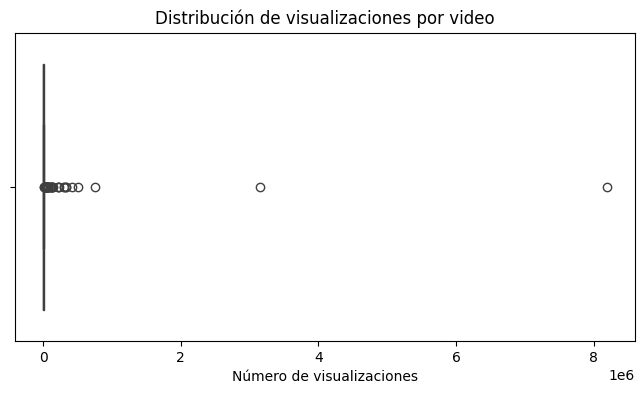

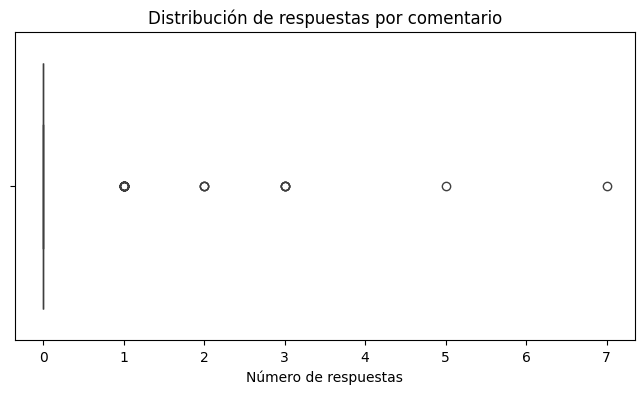

,nombres,handles
channel_id,,


In [11]:
# Dimensiones
print("Dimensiones de videos:", videos.shape)
print("Dimensiones de comentarios:", comentarios.shape)
print("Dimensiones después de la integración:", datos.shape)

# Tipos de variables
print("VIDEOS")
print(videos.dtypes)

print("\nCOMENTARIOS")
print(comentarios.dtypes)

# Valores faltantes
def resumen_faltantes(df):
    return pd.DataFrame({
        "faltantes": df.isna().sum(),
        "porcentaje": (df.isna().mean() * 100).round(2)
    }).sort_values(
        "porcentaje",
        ascending=False
    )
resumen_faltantes(videos)
resumen_faltantes(comentarios)

print("Filas duplicadas en videos:")
print(videos.duplicated().sum())

print("\nFilas duplicadas en comentarios:")
print(comentarios.duplicated().sum())

print(
    "Textos de comentarios duplicados:",
    comentarios["text"].duplicated().sum()
)

constantes_videos = [
    columna
    for columna in videos.columns
    if videos[columna].nunique(dropna=False) <= 1
]

constantes_videos

constantes_comentarios = [
    columna
    for columna in comentarios.columns
    if comentarios[columna].nunique(dropna=False) <= 1
]

constantes_comentarios

videos["view_count"].describe()

plt.figure(figsize=(8, 4))

sns.boxplot(
    x=videos["view_count"]
)

plt.title("Distribución de visualizaciones por video")
plt.xlabel("Número de visualizaciones")
plt.show()

comentarios["reply_count"].describe()

plt.figure(figsize=(8, 4))

sns.boxplot(
    x=comentarios["reply_count"]
)

plt.title("Distribución de respuestas por comentario")
plt.xlabel("Número de respuestas")
plt.show()

comentarios.nlargest(
    10,
    "reply_count"
)[
    ["text", "author_name", "reply_count"]
]

consistencia_canales = (
    videos.groupby("channel_id")
    .agg(
        nombres=("channel_name", "nunique"),
        handles=("channel_handle", "nunique")
    )
)

consistencia_canales.describe()


consistencia_canales[
    (consistencia_canales["nombres"] > 1) |
    (consistencia_canales["handles"] > 1)
]

En la revisión inicial se puede observar que no hay valores faltantes en las variables que serán importantes para el análisis, y que las dimensiones son correctas y tienen sentido después de haber asociado los comentarios y los videos. Aunque en los diagramas parece haber valores atípicos, considerando que es un dataset de videos y comentarios estos pueden hablar de la popularidad de los videos, por lo que de momento no serán eliminados.

Algunas variables requieren tratamiento especial, como viewer_rating, esta está vacía en todos los comentarios, por lo que no se utilizará. is_pinned es False en todos los comentarios, así que no se utilizará. published_time y published_text muestran tiempos como "hace 2 días", que no pueden interpretarse literalmente, así que en vez de utilizarlas para análisis temporal se utilizará publish_date. reply_count solo indica cuántas respuestas tiene un comentario, pero no quién respondió, así que no se utilizará para construir relaciones entre autores.

In [12]:
# normalizar ID
videos["video_id"] = videos["video_id"].astype(str).str.strip()
videos["channel_id"] = videos["channel_id"].astype(str).str.strip()

comentarios["video_id"] = comentarios["video_id"].astype(str).str.strip()
comentarios["comment_id"] = comentarios["comment_id"].astype(str).str.strip()

# normalizar nombres y handles
videos["channel_name"] = videos["channel_name"].astype("string").str.strip()
videos["channel_handle"] = videos["channel_handle"].astype("string").str.strip()

comentarios["author_name"] = comentarios["author_name"].astype("string").str.strip()
comentarios["author_handle"] = comentarios["author_handle"].astype("string").str.strip()

# Comprobación
print("video_id faltantes:", videos["video_id"].isna().sum())
print("channel_id faltantes:", videos["channel_id"].isna().sum())

print("comment_id faltantes:", comentarios["comment_id"].isna().sum())
print(
    "author_channel_id faltantes:",
    comentarios["author_channel_id"].isna().sum()
)

video_id faltantes: 0
channel_id faltantes: 0
comment_id faltantes: 0
author_channel_id faltantes: 0


Se normalizaron los ID para garantizar que no haya problemas con el análisis más adelante, los identificadores mencionados anteriormente seguirán siendo utilizados. Los nombres y handles también se normalizaron, pero se conservó su formato originla para poder usarlos como atributos descriptivos.

In [24]:
comentarios["like_count"] = pd.to_numeric(
    comentarios["like_count_text"],
    errors="coerce"
)

comentarios[
    ["like_count_text", "like_count"]
].head(20)

print("Valores no convertidos:")
print(comentarios["like_count"].isna().sum())

comentarios["texto_original"] = comentarios["text"].copy()
comentarios["texto_limpio"] = comentarios["text"].copy()

comentarios[
    ["text", "texto_original", "texto_limpio"]
].head()

comentarios["texto_limpio"] = (
    comentarios["texto_limpio"]
    .str.lower()
)
comentarios[
    ["texto_original", "texto_limpio"]
].head(10)

tiene_url = comentarios["texto_original"].str.contains(
    r"https?://\S+|www\.\S+",
    regex=True,
    na=False
)

print("Comentarios con URL:", tiene_url.sum())

comentarios["texto_limpio"] = (
    comentarios["texto_limpio"]
    .str.replace(
        r"https?://\S+|www\.\S+",
        "",
        regex=True
    )
)

comentarios["hashtags"] = comentarios["texto_original"].str.findall(
    r"#\w+"
)

comentarios[
    ["texto_original", "hashtags"]
].head(10)

comentarios["tiene_hashtag"] = (
    comentarios["hashtags"].str.len() > 0
)

print(
    "Comentarios con hashtags:",
    comentarios["tiene_hashtag"].sum()
)

comentarios["texto_limpio"] = (
    comentarios["texto_limpio"]
    .str.replace(
        r"[^\w\s]",
        " ",
        regex=True
    )
)

comentarios["texto_limpio"] = (
    comentarios["texto_limpio"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

comentarios["texto_limpio"] = (
    comentarios["texto_limpio"]
    .apply(
        lambda texto: " ".join(
            palabra
            for palabra in texto.split()
            if palabra not in stop_words
        )
    )
)

modificados = (
    comentarios["texto_original"] != comentarios["texto_limpio"]
).sum()

print("Total de comentarios:", len(comentarios))
print("Textos modificados:", modificados)
print(
    "Porcentaje modificado:",
    round(modificados / len(comentarios) * 100, 2),
    "%"
)

vacios_antes = (
    comentarios["texto_original"]
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)

print("Textos vacíos antes:", vacios_antes)

vacios_despues = (
    comentarios["texto_limpio"]
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)

print("Textos vacíos después:", vacios_despues)

duplicados_antes = comentarios[
    "texto_original"
].duplicated().sum()

print("Textos duplicados antes:", duplicados_antes)

duplicados_despues = comentarios[
    "texto_limpio"
].duplicated().sum()

print("Textos duplicados después:", duplicados_despues)

Valores no convertidos:
189
Comentarios con URL: 1
Comentarios con hashtags: 1
Total de comentarios: 406
Textos modificados: 402
Porcentaje modificado: 99.01 %
Textos vacíos antes: 0
Textos vacíos después: 5
Textos duplicados antes: 2
Textos duplicados después: 10


La limpieza modificó la mayoría de los comentarios debido a la normalización de mayúsculas, eliminación de elementos no textuales y stopwords. Se comparó además la cantidad de textos vacíos y duplicados antes y después del procesamiento para verificar que la limpieza no eliminara una cantidad importante de información y para identificar comentarios que se volvieron equivalentes después de la normalización.

# Ejercicio 3

3.1 RESUMEN GENERAL
Videos: 293
Canales: 97
Comentarios: 406
Autores únicos: 332

Top 10 canales por número de videos:


channel_id                channel_name                         
UC-ZtFBHzgkYFh7whZkuR_Ag  Gobierno de la República de Guatemala    32
UCXa6LVjBzUtmcM3cwbd9e2w  Municipalidad de Guatemala               27
UCE4rsXcgDb6e1-a9iTbWzfg  Quorum                                   18
UCEepOY2svuxbsJ-zsAPT9Fg  PrensaLibreOficial                       17
UC8u2nvyHewt-mjdWSj0HJmQ  Ministerio de Gobernación                14
UCaivrAhro2BpsJdrPe-IyRg  Diario de Centro América                 11
UCAutgrPkiLhZxTB-Ujje1fw  CIV -Ministerio de Comunicaciones        11
UCW_PHqwqCCalvQGOEsVU0jw  Concejales de Oposición - Muni Guate     10
UCHsYnV67K3J0yJ4QeciVCww  PNCdeGuatemala                           10
UC6SA1dVHvAkc6yNS_t5cbGw  Conred                                    8
dtype: int64

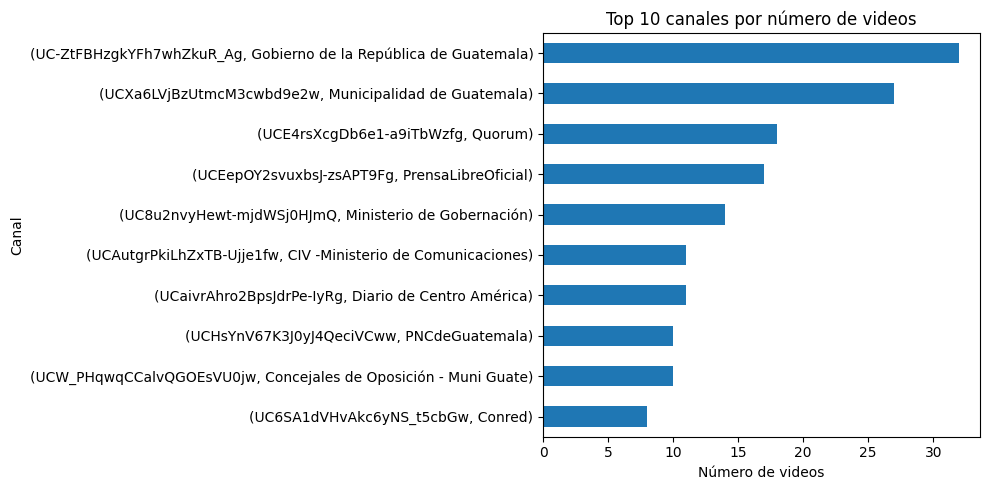


Participación por video:

Top 10 videos con mayor cantidad de comentarios:


,,comentarios,autores_unicos
video_id,video_title,,
n8iP75gIpmw,Qué rico come tu diputado,161,128
j43HgwYFKfk,La cooptación de Walter Mazariegos en la USAC,50,49
6W4u8sGEnGM,Inician los trabajos de recuperación del Puente Belice II.,45,32
lj983NWyAQY,Plan 2032 Ciudad de Guatemala,25,25
PjmxCj-a9Hg,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,25,19
OkXlHx0hx-8,EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticias Telemundo,25,18
yLZS3JiEBg8,Arroz con pollo a la MONOPOLIO,16,16
06mFNPU0aB8,Capturan a presuntos delincuentes disfrazados de mujer señalados de cometer asalto,14,13
ndAZjHqzzT8,Internet: escoger el menos malo,12,10


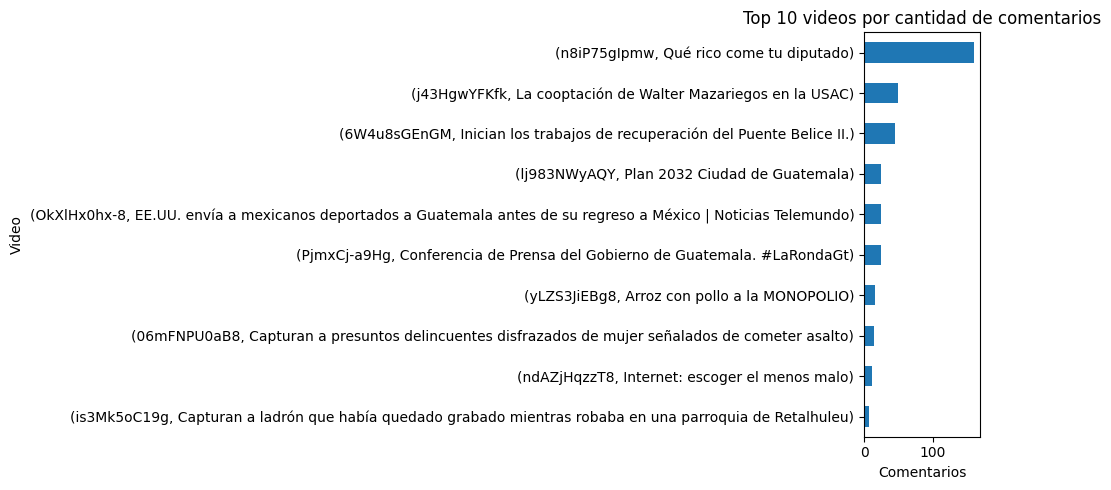


Estadísticas de visualizaciones:


count    2.930000e+02
mean     6.043009e+04
std      5.157983e+05
min      2.000000e+00
25%      2.150000e+02
50%      1.175000e+03
75%      7.465000e+03
max      8.190449e+06
Name: view_count, dtype: float64

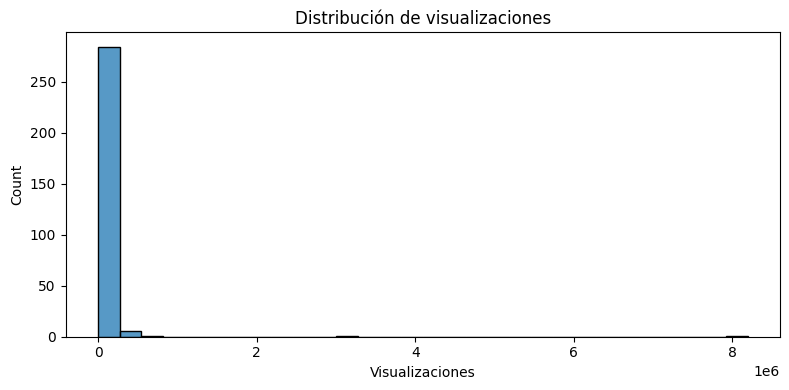


Top 10 videos con más visualizaciones:


,title,channel_name,view_count
148,"Los ALUCINANTES autobuses de Guatemala | ""Burras""",Luisito Comunica,8190449
245,🚫LOS FAMOSOS BUSES ESMERALDA los mas RÁPIDOS D...,De todo Gt,3152619
113,🇬🇹HISTORIA de GUATEMALA en 17 minutos🇬🇹 - El M...,El Mapa de Sebas,749356
56,Este BUS me LLEVO a UN PARAISO EN GUATEMALA,De todo Gt,504374
126,✅ ASÍ es una EXHIBICION DE BUSES EN GUATEMALA,De todo Gt,424874
180,Sonido de trafico y ciudad 💤 ruido de calle pa...,Ambient Sound Explorer,330057
159,ME quité el MIEDO de viajar en los buses de GU...,De todo Gt,329489
182,Tercer Informe General de la República,Gobierno de Guatemala,305269
239,Plan 2032 Ciudad de Guatemala,Municipalidad de Guatemala,304089
176,Piloto de tráiler accidentado en ruta al Atlán...,PrensaLibreOficial,233632



Estadísticas de respuestas:


count    406.000000
mean       0.125616
std        0.580748
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        7.000000
Name: reply_count, dtype: float64

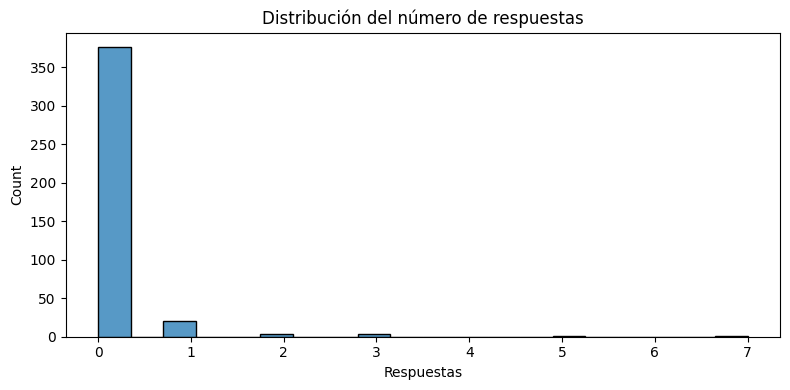


Estadísticas de likes:


count    217.000000
mean      10.714286
std       41.340405
min        1.000000
25%        1.000000
50%        2.000000
75%        4.000000
max      405.000000
Name: like_count, dtype: float64

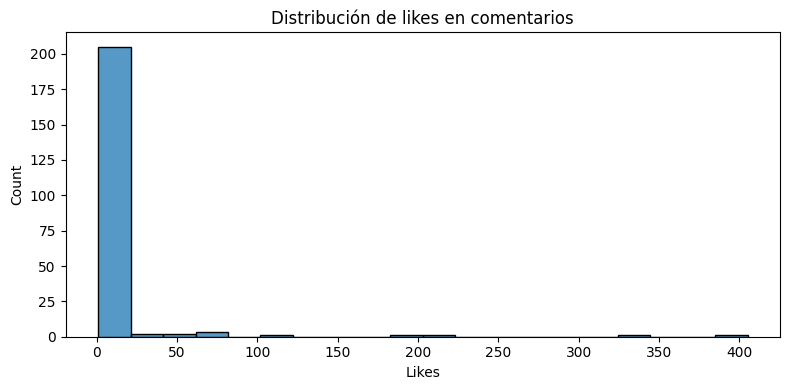


Categorías:


category
News & Politics          138
People & Blogs            66
Entertainment             48
Education                 19
Travel & Events            8
Science & Technology       6
Nonprofits & Activism      3
Film & Animation           2
Comedy                     1
Sports                     1
Music                      1
Name: count, dtype: int64

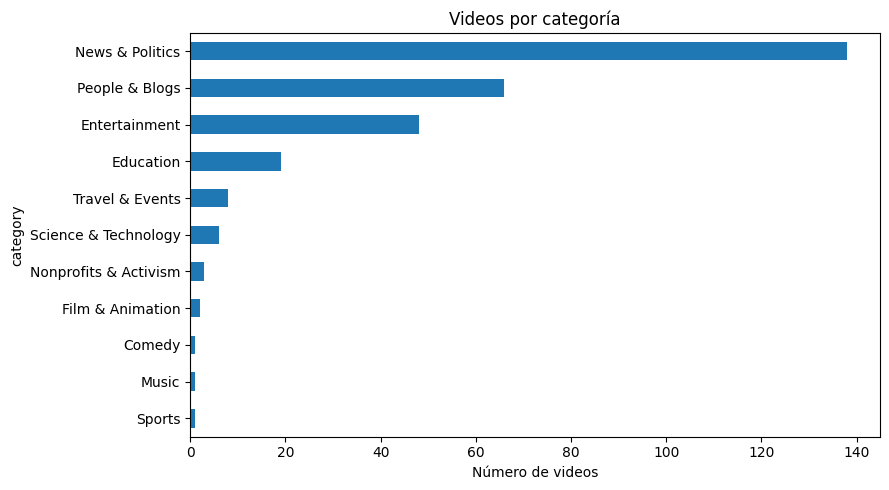


Consultas de búsqueda más frecuentes:


source_query
Municipalidad de Guatemala                20
Gobierno de Guatemala                     18
@GobiernodelaRepublicadeGuatema           18
@GobiernodeGuatemala                      17
guatemala noticias                        16
Ministerio de Comunicaciones Guatemala    16
@MunicipalidaddeGuatemala-1551            16
Gobierno de la República de Guatemala     15
PMT Guatemala                             15
Conred Guatemala                          15
Provial Guatemala                         13
guatemala trafico                         13
guatemala transporte                      13
Policia Nacional Civil Guatemala          13
guatemala lluvias                         12
Name: count, dtype: int64

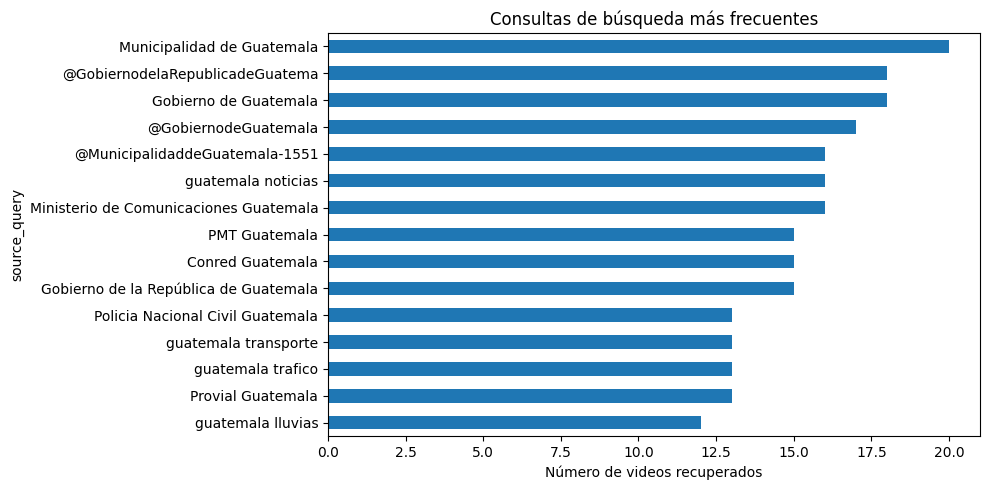


Hashtags más frecuentes:


,hashtag,frecuencia
0,#ineptobran,1


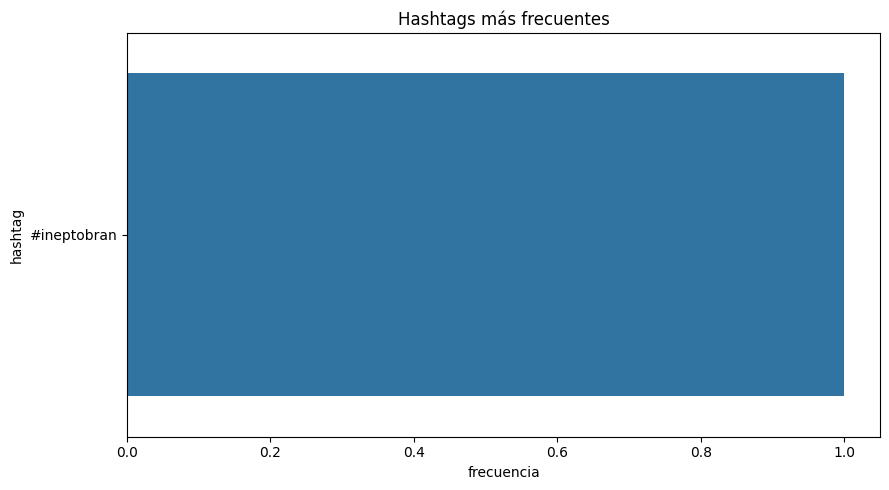


Palabras más frecuentes:


,palabra,frecuencia
0,si,74
1,pueblo,56
2,guatemala,52
3,dinero,34
4,solo,33
5,presidente,32
6,país,31
7,trabajo,30
8,diputados,28
9,corruptos,24


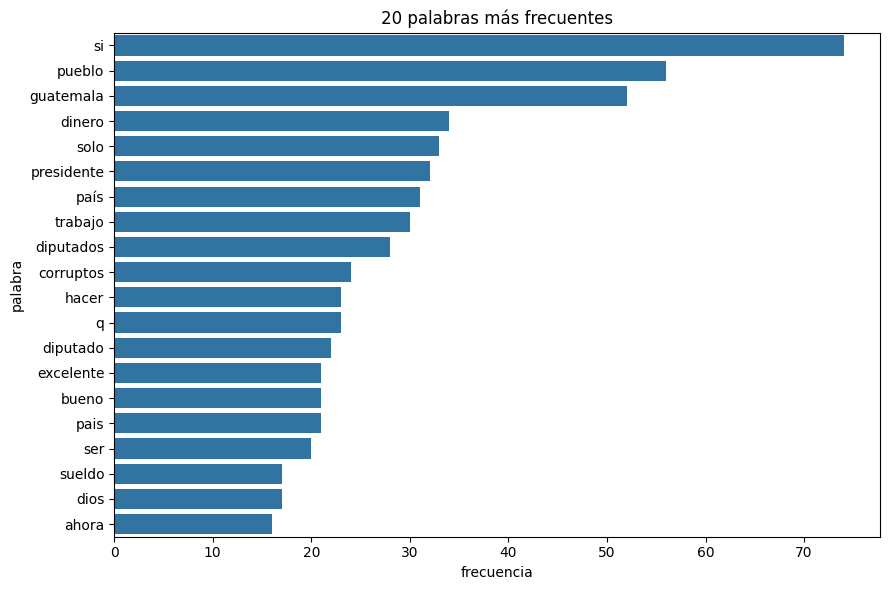


Bigramas más frecuentes:


,bigrama,frecuencia
94,presidente bernardo,9
15,bernardo arevalo,8
27,ciudad guatemala,6
17,bla bla,5
83,nery rodas,5
87,pacto corruptos,5
22,busquen trabajo,4
28,comida nadie,4
44,dinero pueblo,4
74,lleva años,4


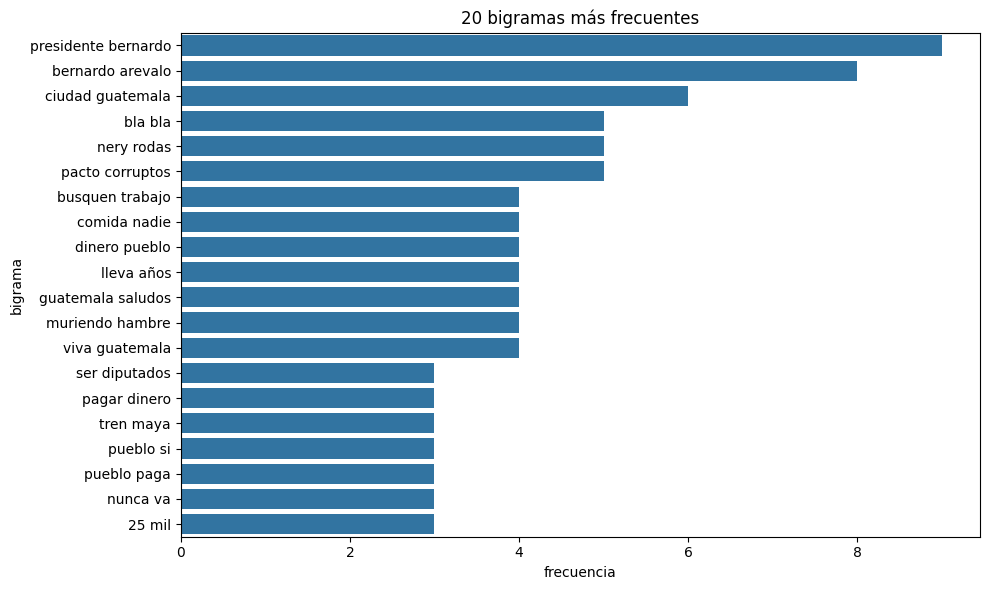

Top 1 videos concentran 39.66% de los comentarios
Top 1 canales concentran 63.05% de los comentarios
Top 5 videos concentran 75.37% de los comentarios
Top 5 canales concentran 96.06% de los comentarios
Top 10 videos concentran 93.60% de los comentarios
Top 10 canales concentran 100.00% de los comentarios


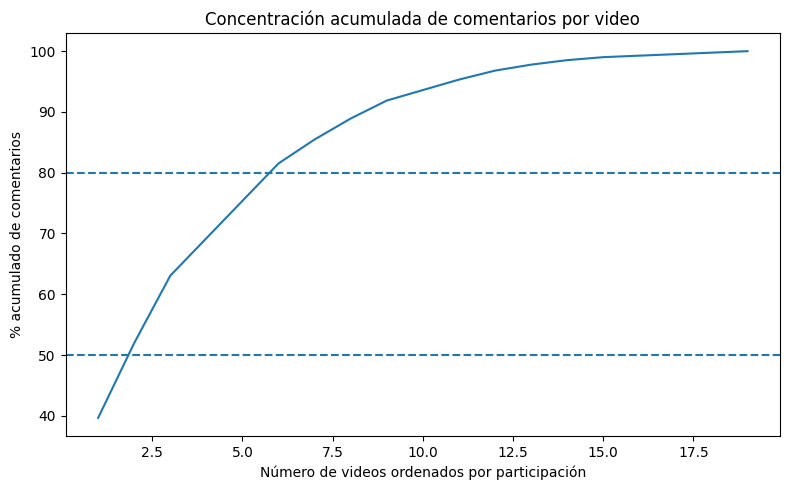


Correlación entre visualizaciones y comentarios observados:


,view_count,comentarios_observados
view_count,1.000000,-0.008393
comentarios_observados,-0.008393,1.000000


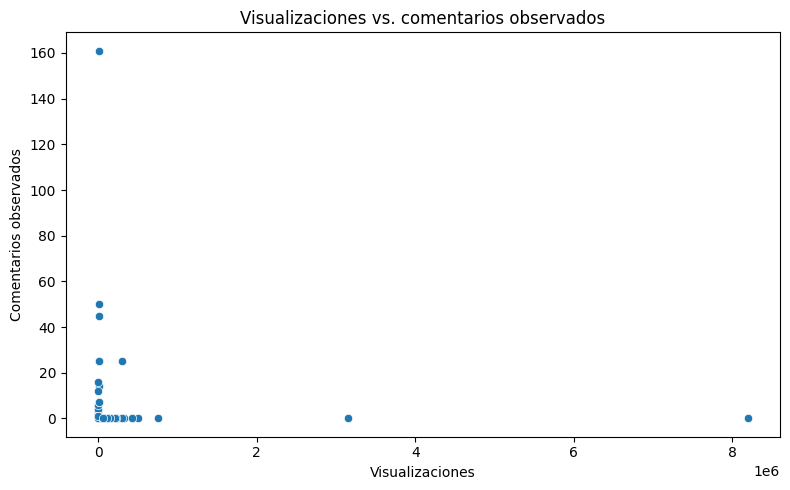


Videos con mayor participación observada:


,title,channel_name,view_count,comentarios_observados
246,Qué rico come tu diputado,Quorum,11775,161.0
229,La cooptación de Walter Mazariegos en la USAC,Quorum,10156,50.0
38,Inician los trabajos de recuperación del Puent...,Gobierno de la República de Guatemala,11670,45.0
130,EE.UU. envía a mexicanos deportados a Guatemal...,Noticias Telemundo,14200,25.0
136,Conferencia de Prensa del Gobierno de Guatemal...,Gobierno de la República de Guatemala,3628,25.0
239,Plan 2032 Ciudad de Guatemala,Municipalidad de Guatemala,304089,25.0
289,Arroz con pollo a la MONOPOLIO,Quorum,1954,16.0
4,Capturan a presuntos delincuentes disfrazados ...,Noti7,6692,14.0
250,Internet: escoger el menos malo,Quorum,717,12.0
197,Bloqueos en Guatemala este 31 de agosto por al...,PrensaLibreOficial,5469,7.0



Canales con más comentarios:


channel_id                channel_name                         
UCE4rsXcgDb6e1-a9iTbWzfg  Quorum                                   256
UC-ZtFBHzgkYFh7whZkuR_Ag  Gobierno de la República de Guatemala     70
UCRwA1NUcUnwsly35ikGhp0A  Noticias Telemundo                        25
UCXa6LVjBzUtmcM3cwbd9e2w  Municipalidad de Guatemala                25
UCVpSRoZgngfSL03Nlbjtq9A  Noti7                                     14
UCEepOY2svuxbsJ-zsAPT9Fg  PrensaLibreOficial                         7
UCt5Dw7ePnn0AqPqRF8Xpjkw  TN23 Guatemala                             7
UCdSVqHGHzyMTXSafUHY-e-w  Noticiero Guatevisión 13 Hrs.              2
dtype: int64


Autores que comentaron en más videos:


...

,total_comentarios,videos_distintos
total_comentarios,1.000000,0.349127
videos_distintos,0.349127,1.000000



2. ¿Los comentarios con más likes reciben también más respuestas?


,like_count,reply_count
like_count,1.000000,0.549087
reply_count,0.549087,1.000000



3. ¿Qué categorías presentan mayor participación observada?


,comentarios,autores
category,,
News & Politics,335,283
Entertainment,70,50
Nonprofits & Activism,1,1


In [26]:

print("3.1 RESUMEN GENERAL")

n_videos = videos["video_id"].nunique()
n_canales = videos["channel_id"].nunique()
n_comentarios = comentarios["comment_id"].nunique()
n_autores = comentarios["author_channel_id"].nunique()

print("Videos:", n_videos)
print("Canales:", n_canales)
print("Comentarios:", n_comentarios)
print("Autores únicos:", n_autores)


videos_por_canal = (
    videos.groupby(["channel_id", "channel_name"])
    .size()
    .sort_values(ascending=False)
)

print("\nTop 10 canales por número de videos:")
display(videos_por_canal.head(10))

plt.figure(figsize=(10, 5))
videos_por_canal.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 canales por número de videos")
plt.xlabel("Número de videos")
plt.ylabel("Canal")
plt.tight_layout()
plt.show()

print("\nParticipación por video:")
participacion_video = (
    comentarios.groupby(["video_id", "video_title"])
    .agg(
        comentarios=("comment_id", "count"),
        autores_unicos=("author_channel_id", "nunique")
    )
    .sort_values("comentarios", ascending=False)
)

print("\nTop 10 videos con mayor cantidad de comentarios:")
display(participacion_video.head(10))

plt.figure(figsize=(10, 5))
participacion_video["comentarios"].head(10).sort_values().plot(
    kind="barh"
)
plt.title("Top 10 videos por cantidad de comentarios")
plt.xlabel("Comentarios")
plt.ylabel("Video")
plt.tight_layout()
plt.show()

# VISUALIZACIONES

print("\nEstadísticas de visualizaciones:")
display(videos["view_count"].describe())

plt.figure(figsize=(8, 4))
sns.histplot(videos["view_count"], bins=30)
plt.title("Distribución de visualizaciones")
plt.xlabel("Visualizaciones")
plt.tight_layout()
plt.show()

print("\nTop 10 videos con más visualizaciones:")
display(
    videos.nlargest(10, "view_count")[
        ["title", "channel_name", "view_count"]
    ]
)

# RESPUESTAS

print("\nEstadísticas de respuestas:")
display(comentarios["reply_count"].describe())

plt.figure(figsize=(8, 4))
sns.histplot(comentarios["reply_count"], bins=20)
plt.title("Distribución del número de respuestas")
plt.xlabel("Respuestas")
plt.tight_layout()
plt.show()

# LIKES

print("\nEstadísticas de likes:")
display(comentarios["like_count"].describe())

plt.figure(figsize=(8, 4))
sns.histplot(comentarios["like_count"].dropna(), bins=20)
plt.title("Distribución de likes en comentarios")
plt.xlabel("Likes")
plt.tight_layout()
plt.show()

# CATEGORIAS

categorias = videos["category"].value_counts()

print("\nCategorías:")
display(categorias)

plt.figure(figsize=(9, 5))
categorias.sort_values().plot(kind="barh")
plt.title("Videos por categoría")
plt.xlabel("Número de videos")
plt.tight_layout()
plt.show()

# CONSULTAS DE BUSQUEDA

consultas = videos["source_query"].value_counts()

print("\nConsultas de búsqueda más frecuentes:")
display(consultas.head(15))

plt.figure(figsize=(10, 5))
consultas.head(15).sort_values().plot(kind="barh")
plt.title("Consultas de búsqueda más frecuentes")
plt.xlabel("Número de videos recuperados")
plt.tight_layout()
plt.show()

# HASHTAGS

todos_hashtags = [
    hashtag.lower()
    for lista in comentarios["hashtags"]
    for hashtag in lista
]

frecuencia_hashtags = Counter(todos_hashtags)

df_hashtags = pd.DataFrame(
    frecuencia_hashtags.most_common(15),
    columns=["hashtag", "frecuencia"]
)

print("\nHashtags más frecuentes:")
display(df_hashtags)

if len(df_hashtags) > 0:
    plt.figure(figsize=(9, 5))
    sns.barplot(
        data=df_hashtags,
        x="frecuencia",
        y="hashtag"
    )
    plt.title("Hashtags más frecuentes")
    plt.tight_layout()
    plt.show()

# PALABRAS MAS FRECUENTES

texto_total = " ".join(
    comentarios["texto_limpio"]
    .dropna()
    .astype(str)
)

frecuencia_palabras = Counter(texto_total.split())

df_palabras = pd.DataFrame(
    frecuencia_palabras.most_common(20),
    columns=["palabra", "frecuencia"]
)

print("\nPalabras más frecuentes:")
display(df_palabras)

plt.figure(figsize=(9, 6))
sns.barplot(
    data=df_palabras,
    x="frecuencia",
    y="palabra"
)
plt.title("20 palabras más frecuentes")
plt.tight_layout()
plt.show()

# BIGRAMAS MAS FRECUENTES
vectorizador = CountVectorizer(
    ngram_range=(2, 2),
    min_df=2
)

X_bigramas = vectorizador.fit_transform(
    comentarios["texto_limpio"].fillna("")
)

frecuencias_bigramas = np.asarray(
    X_bigramas.sum(axis=0)
).flatten()

df_bigramas = pd.DataFrame({
    "bigrama": vectorizador.get_feature_names_out(),
    "frecuencia": frecuencias_bigramas
}).sort_values(
    "frecuencia",
    ascending=False
).head(20)

print("\nBigramas más frecuentes:")
display(df_bigramas)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_bigramas,
    x="frecuencia",
    y="bigrama"
)
plt.title("20 bigramas más frecuentes")
plt.tight_layout()
plt.show()

# CONCENTRACION DE LA PARTICIPACION

comentarios_por_video = (
    comentarios.groupby("video_id")
    .size()
    .sort_values(ascending=False)
)

comentarios_por_canal = (
    comentarios.groupby("channel_id")
    .size()
    .sort_values(ascending=False)
)

for n in [1, 5, 10]:

    porcentaje_videos = (
        comentarios_por_video.head(n).sum()
        / len(comentarios)
        * 100
    )

    porcentaje_canales = (
        comentarios_por_canal.head(n).sum()
        / len(comentarios)
        * 100
    )

    print(
        f"Top {n} videos concentran "
        f"{porcentaje_videos:.2f}% de los comentarios"
    )

    print(
        f"Top {n} canales concentran "
        f"{porcentaje_canales:.2f}% de los comentarios"
    )


# Curva acumulada de concentración por video

participacion_acumulada = (
    comentarios_por_video.cumsum()
    / comentarios_por_video.sum()
    * 100
)

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(participacion_acumulada) + 1),
    participacion_acumulada
)

plt.axhline(50, linestyle="--")
plt.axhline(80, linestyle="--")

plt.title("Concentración acumulada de comentarios por video")
plt.xlabel("Número de videos ordenados por participación")
plt.ylabel("% acumulado de comentarios")
plt.tight_layout()
plt.show()

# POPULARIDAD VS PARTICIPACION

conteo_comentarios = (
    comentarios.groupby("video_id")
    .size()
    .rename("comentarios_observados")
)

popularidad = videos[
    ["video_id", "title", "channel_name", "view_count"]
].merge(
    conteo_comentarios,
    on="video_id",
    how="left"
)

popularidad["comentarios_observados"] = (
    popularidad["comentarios_observados"]
    .fillna(0)
)

correlacion = popularidad[
    ["view_count", "comentarios_observados"]
].corr()

print("\nCorrelación entre visualizaciones y comentarios observados:")
display(correlacion)

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=popularidad,
    x="view_count",
    y="comentarios_observados"
)

plt.title("Visualizaciones vs. comentarios observados")
plt.xlabel("Visualizaciones")
plt.ylabel("Comentarios observados")
plt.tight_layout()
plt.show()

# RESUMEN DE LOS VIDEOS CON MAYOR PARTICIPACION

top_participacion = (
    popularidad
    .sort_values(
        "comentarios_observados",
        ascending=False
    )
    .head(10)
)

print("\nVideos con mayor participación observada:")
display(
    top_participacion[
        [
            "title",
            "channel_name",
            "view_count",
            "comentarios_observados"
        ]
    ]
)

# INFORMACION PARA RESPONDER 3.5

print("\nCanales con más comentarios:")
display(
    comentarios.groupby(
        ["channel_id", "channel_name"]
    )
    .size()
    .sort_values(ascending=False)
    .head(10)
)

print("\nAutores que comentaron en más videos:")
autores_diversidad = (
    comentarios.groupby(
        ["author_channel_id", "author_name"]
    )["video_id"]
    .nunique()
    .sort_values(ascending=False)
)

display(autores_diversidad.head(10))

print("\nAutores con mayor número total de comentarios:")
autores_comentarios = (
    comentarios.groupby(
        ["author_channel_id", "author_name"]
    )
    .size()
    .sort_values(ascending=False)
)

display(autores_comentarios.head(10))

# TRES PREGUNTAS ADICIONALES - 3.6

print(
    "\n1. ¿Los autores que más comentan también participan "
    "en una mayor diversidad de videos?"
)

actividad_autores = (
    comentarios.groupby("author_channel_id")
    .agg(
        total_comentarios=("comment_id", "count"),
        videos_distintos=("video_id", "nunique")
    )
)

display(
    actividad_autores[
        ["total_comentarios", "videos_distintos"]
    ].corr()
)

print(
    "\n2. ¿Los comentarios con más likes reciben también "
    "más respuestas?"
)

display(
    comentarios[
        ["like_count", "reply_count"]
    ].corr()
)

print(
    "\n3. ¿Qué categorías presentan mayor participación "
    "observada?"
)

participacion_categoria = (
    datos.groupby("category")
    .agg(
        comentarios=("comment_id", "count"),
        autores=("author_channel_id", "nunique")
    )
    .sort_values(
        "comentarios",
        ascending=False
    )
)

display(participacion_categoria)

El dataset tiene 293 videos que pertenecen a 97 canales, y hay 406 comentarios. La cantidad de videos se concentra más en algunos canales que en otros, por lo que no está representado de forma uniforme. El caso más destacado es "Qué rico come tu diputado", que contiene 161 comentarios de 128 autores únicos. Esto equivale aproximadamente al 39.7 % de los 406 comentarios disponibles en todo el dataset.
El segundo video con mayor participación, "La cooptación de Walter Mazariegos en la USAC", presenta 50 comentarios, mientras que "Inician los trabajos de recuperación del Puente Belice II" presenta 45. Existe por lo tanto una diferencia considerable entre el video con mayor participación y el resto.
Además, la comparación entre comentarios y autores únicos muestra que en varios videos la mayoría de participantes realiza un solo comentario. Por ejemplo, el video sobre Walter Mazariegos contiene 50 comentarios provenientes de 49 autores únicos. En otros casos existe mayor participación repetida, como en "Qué rico come tu diputado", donde 161 comentarios corresponden a 128 autores.
Estos resultados muestran que la estructura de participación que se obtenga posteriormente estará fuertemente influenciada por unos pocos videos con una cantidad elevada de comentarios.

Las visualizaciones presentan una distribución muy desigual. Aunque el promedio es de aproximadamente 60,430 visualizaciones por video, la mediana es únicamente de 1,175. Esta diferencia se debe a la existencia de unos pocos videos con cantidades muy altas de visualizaciones a comparación de otros.
El máximo corresponde a "Los ALUCINANTES autobuses de Guatemala | 'Burras'", con aproximadamente 8.19 millones de visualizaciones. El segundo video alcanza aproximadamente 3.15 millones, mientras que la mayoría de los videos se encuentra muy por debajo de estos valores.
Por esta razón, la media no representa adecuadamente a un video típico del conjunto. La mediana proporciona una descripción más acertada según el contexto. Los valores extremos no se consideran necesariamente errores, ya que pueden corresponder legítimamente a videos que alcanzaron una difusión mucho mayor.

La interacción mediante respuestas es baja para la mayoría de los comentarios. La mediana, el primer cuartil y el tercer cuartil de reply_count son iguales a 0, mientras que el promedio es aproximadamente 0.13 respuestas por comentario. El máximo observado es de 7 respuestas.
Esto indica que la mayor parte de los comentarios principales no recibió respuestas. Además, reply_count únicamente representa la cantidad de respuestas, pero no nos dice quién respondió a quién, por lo que no puede utilizarse para inferir relaciones directas entre autores.
Los likes presentan también una distribución muy asimétrica. Entre los 217 comentarios para los que existe un conteo disponible, la mediana es de 2 likes y el 75 % presenta 4 o menos, pero existe un máximo de 405 likes. Esto genera que el promedio de aproximadamente 10.7 likes se encuentra elevado por unos pocos comentarios con mucha interacción.
La categoría predominante es News & Politics, con 138 de los 293 videos, aproximadamente el 47 % del conjunto. Le siguen People & Blogs, con 66 videos, y Entertainment, con 48. Las demás categorías tienen una presencia considerablemente menor.
Por lo tanto, los resultados posteriores estarán especialmente influenciados por contenido político, informativo y de actualidad. No se puede interpretar este dataset como igualmente representativo para todas las categorías.

Las consultas utilizadas para recolectar los videos también muestran una fuerte presencia de instituciones y temas relacionados con Guatemala. Entre las consultas más frecuentes aparecen Municipalidad de Guatemala, Gobierno de Guatemala, Ministerio de Comunicaciones, Policía Nacional Civil, Conred, noticias, transporte, tráfico y lluvias.
Esto permite comprender parte de la composición observada en las categorías y canales. Sin embargo, source_query solo representa el mecanismo utilizado para encontrar los videos y no necesariamente el tema definitivo de cada contenido. Por lo tanto, estas consultas deben interpretarse principalmente como una característica del procedimiento de recolección.

El análisis del texto limpio muestra que entre los términos más frecuentes aparecen `pueblo`, `guatemala`, `dinero`, `presidente`, `país`, `trabajo`, `diputados` y `corruptos`. En conjunto, estas palabras muestran una presencia importante de conversaciones relacionadas con política, instituciones públicas, economía y asuntos nacionales.
También aparecen términos como `excelente`, `bueno` y `dios`, que pueden estar relacionados con valoraciones u opiniones de los usuarios.
Sin embargo, algunos resultados como `si`, `q` y la aparición repetida de formas similares de `pais` sugieren que el preprocesamiento todavía podría mejorarse. Por ejemplo, `q` probablemente solo se refiere a `que` y aporta poco significado por sí sola. También sería conveniente revisar la normalización de caracteres con y sin tilde para evitar tratar variantes de una misma palabra como términos diferentes.

Los bigramas proporcionan más contexto que las palabras individuales. Los más frecuentes incluyen `presidente bernardo`, `bernardo arevalo`, `ciudad guatemala`, `pacto corruptos`, `busquen trabajo`, `dinero pueblo` y `muriendo hambre`.
Estos resultados refuerzan la presencia de conversaciones políticas y sociales en los comentarios. En particular, combinaciones como `presidente bernardo` y `bernardo arevalo` muestran referencias a personajes políticos, mientras que expresiones como `pacto corruptos`, `dinero pueblo` y `muriendo hambre` también indican discusiones relacionadas con política, economía y descontento.
Sin embargo, las frecuencias de los bigramas son relativamente pequeñas, los más frecuentes aparecen menos de diez veces. Por esta razón, deben utilizarse como evidencia exploratoria del contenido de las conversaciones y no como prueba de que estos temas caracterizan a todos los usuarios o videos del conjunto.

El análisis exploratorio muestra principalmente tres características del conjunto. Primero, tanto la representación de videos por canal y la participación de comentarios están concentradas en una parte pequeña del contenido observado. Segundo, la popularidad medida mediante visualizaciones presenta una distribución extremadamente desigual, con unos pocos videos que alcanzan millones de visualizaciones mientras la mayoría presenta cantidades mucho menores. Tercero, el contenido textual disponible está fuertemente relacionado con temas políticos, institucionales y sociales de Guatemala.

Estas características serán importantes al construir e interpretar la red autor-video. En particular, los videos con una cantidad elevada de comentarios probablemente tendrán un papel estructural importante simplemente porque concentran una parte considerable de la participación observada.

Finalmente, los resultados describen únicamente este dataset. La selección de videos depende de las consultas y canales utilizados durante la recolección y la cantidad de comentarios disponible no necesariamente representa toda la actividad existente en YouTube. Esto siguifica que los resultados no deben generalizarse a todos los usuarios de YouTube ni a la población de Guatemala.

# Ejercicio 4

Número de aristas autor-video: 343


,author_channel_id,video_id,peso
0,UC-HeUTT6_g-VoiWds2a4H-w,6W4u8sGEnGM,1
1,UC-Iul5tDYH_oiAMXQH-KaaQ,6W4u8sGEnGM,1
2,UC-QOpE7GOxlXcHZ8b7HbQKA,OkXlHx0hx-8,2
3,UC-fiZBS5Gp1eCJd9ucgWnCg,j43HgwYFKfk,1
4,UC-hfX8J5JPJ-dfuakzegMLA,n8iP75gIpmw,1
5,UC-jS_kA9w-OmpupXDx156Rg,n8iP75gIpmw,1
6,UC-pNP6RMFuLg_-x7Ah_0kEA,n8iP75gIpmw,1
7,UC094EFEmMSdwVa8NQjjYBXg,b_Hkrkl3adA,1
8,UC0HvfEWozTHbwl_iEmJNvVA,6W4u8sGEnGM,1
9,UC0RpuMwkDKJYqgKHtsJRuWQ,lj983NWyAQY,1


,id,nombre,handle,tipo
0,UCdFlugHJJa4l3YqWuNRmvXw,@MarcosCarillo-b1r,/@MarcosCarillo-b1r,autor
1,UCvl1tzQeBeGy6efPTRJXSCw,@RaulPerez-cw2vi,/@RaulPerez-cw2vi,autor
2,UCRAquv8el-tQ30bN7MlmySQ,@iamjimalesssa,/@iamjimalesssa,autor
3,UCkbsS_3D-pvg1iHOld9uvIg,@gonzalo6075,/@gonzalo6075,autor
4,UCOLHH4ZpMxPYF-Q6e6wvn5A,@luisroldan7374,/@luisroldan7374,autor


,id,nombre,channel_name,channel_id,category,tipo
0,-5puKGEqcUc,INSIVUMEH pronostica incremento de lluvias par...,T13 Noticias Guatemala,UCq0Cm-3SKthEySQc2JZBi1A,News & Politics,video
1,-E7OPOLjMug,BERNARDO ARÉVALO CALIFICA CAMBIO EN EL MP COMO...,IDocumenta,UCgItjn_ZWFWcv1MlpKIkqgQ,People & Blogs,video
2,-KDglrIzRKo,¡HISTÓRICO! Mexico recupera petróleo robado po...,México Poder,UC-DpoeBbCMOMOH1-j71KPqA,People & Blogs,video
3,-O4Pa7qS9WQ,Viaje completo Ciudad de Guatemala al IRTRA de...,Guate Maya Trip,UCSQM9AVr3rr7_GF8RH5KFGw,Nonprofits & Activism,video
4,06mFNPU0aB8,Capturan a presuntos delincuentes disfrazados ...,Noti7,UCVpSRoZgngfSL03Nlbjtq9A,News & Politics,video


Total de nodos: 625

Nodos por tipo:
tipo
autor    332
video    293
Name: count, dtype: int64


,id,nombre,handle,tipo,channel_name,channel_id,category
0,UCdFlugHJJa4l3YqWuNRmvXw,@MarcosCarillo-b1r,/@MarcosCarillo-b1r,autor,<NA>,NaN,NaN
1,UCvl1tzQeBeGy6efPTRJXSCw,@RaulPerez-cw2vi,/@RaulPerez-cw2vi,autor,<NA>,NaN,NaN
2,UCRAquv8el-tQ30bN7MlmySQ,@iamjimalesssa,/@iamjimalesssa,autor,<NA>,NaN,NaN
3,UCkbsS_3D-pvg1iHOld9uvIg,@gonzalo6075,/@gonzalo6075,autor,<NA>,NaN,NaN
4,UCOLHH4ZpMxPYF-Q6e6wvn5A,@luisroldan7374,/@luisroldan7374,autor,<NA>,NaN,NaN



Resumen de la red bipartita
Nodos: 625
Aristas: 343
Autores: 332
Videos: 293


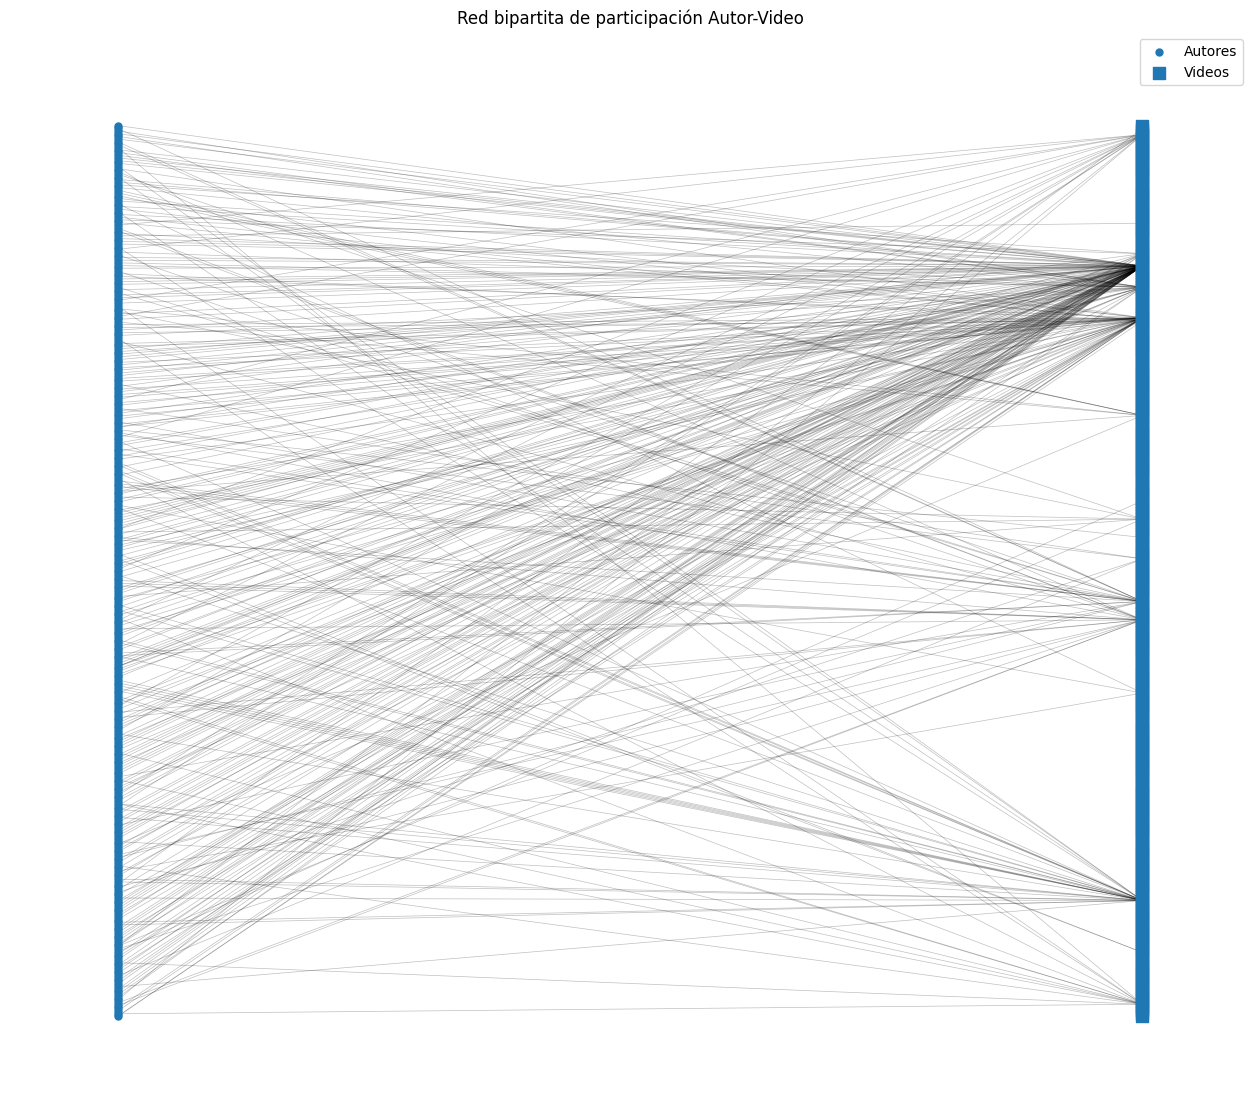

In [28]:
# Tabla de artistas
aristas = (
    comentarios
    .dropna(subset=["author_channel_id", "video_id"])
    .groupby(
        ["author_channel_id", "video_id"]
    )
    .size()
    .reset_index(name="peso")
)

print("Número de aristas autor-video:", len(aristas))

display(aristas.head(10))


# Tabla de nodos de autores

nodos_autores = (
    comentarios[
        [
            "author_channel_id",
            "author_name",
            "author_handle"
        ]
    ]
    .dropna(subset=["author_channel_id"])
    .drop_duplicates(subset=["author_channel_id"])
    .rename(
        columns={
            "author_channel_id": "id",
            "author_name": "nombre",
            "author_handle": "handle"
        }
    )
)

nodos_autores["tipo"] = "autor"

display(nodos_autores.head())


# Tabla de nodos de videos

nodos_videos = (
    videos[
        [
            "video_id",
            "title",
            "channel_name",
            "channel_id",
            "category"
        ]
    ]
    .drop_duplicates(subset=["video_id"])
    .rename(
        columns={
            "video_id": "id",
            "title": "nombre"
        }
    )
)

nodos_videos["tipo"] = "video"

display(nodos_videos.head())


# Unir las tablas

nodos = pd.concat(
    [
        nodos_autores,
        nodos_videos
    ],
    ignore_index=True
)

print("Total de nodos:", len(nodos))
print()
print("Nodos por tipo:")
print(nodos["tipo"].value_counts())

display(nodos.head())


# Red bipartita

G = nx.Graph()

# Agregar autores
for _, fila in nodos_autores.iterrows():

    G.add_node(
        fila["id"],
        bipartite=0,
        tipo="autor",
        nombre=fila["nombre"]
    )


# Agregar videos
for _, fila in nodos_videos.iterrows():

    G.add_node(
        fila["id"],
        bipartite=1,
        tipo="video",
        nombre=fila["nombre"],
        canal=fila["channel_name"],
        categoria=fila["category"]
    )


# Agregar aristas
for _, fila in aristas.iterrows():

    G.add_edge(
        fila["author_channel_id"],
        fila["video_id"],
        weight=fila["peso"]
    )


# Resumen

print("\nResumen de la red bipartita")

print("Nodos:", G.number_of_nodes())
print("Aristas:", G.number_of_edges())

print(
    "Autores:",
    sum(
        1
        for _, datos_nodo in G.nodes(data=True)
        if datos_nodo["tipo"] == "autor"
    )
)

print(
    "Videos:",
    sum(
        1
        for _, datos_nodo in G.nodes(data=True)
        if datos_nodo["tipo"] == "video"
    )
)

# Visualización

autores = [
    nodo
    for nodo, atributos in G.nodes(data=True)
    if atributos["tipo"] == "autor"
]

videos_red = [
    nodo
    for nodo, atributos in G.nodes(data=True)
    if atributos["tipo"] == "video"
]


# Layout bipartito
pos = nx.bipartite_layout(
    G,
    autores
)

plt.figure(figsize=(16, 14))


# Autores
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=autores,
    node_size=25,
    node_shape="o",
    label="Autores"
)


# Videos
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=videos_red,
    node_size=80,
    node_shape="s",
    label="Videos"
)


# Aristas
nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.25,
    width=0.5
)


plt.title(
    "Red bipartita de participación Autor-Video"
)

plt.legend()
plt.axis("off")
plt.show()

La red construida es una red bipartita formada por 2 tipos de nodos: Autores y videos. Una línea entre autor y video significa que el autor publicó al menos un comentario en el video. El peso del arista representa la cantidad de comentarios del autor en el video. Esto no debe interpretarse como amistad o relación, solo indica participación, porque solo indica la cantidad de veces que se comentó, pero no el contexto.

# Ejercicio 5

PROYECCION AUTOR-AUTOR
Autores: 332
Aristas autor-autor: 10732


,autor_1,autor_2,videos_compartidos
1519,UCvcu1kR8xMYy_I1Ty-2mV2Q,UCbrtvygfRT6QXqWDNrOf-cA,2
7162,UCpsKOkt5iWTbenzeuq7dsmQ,UCylqlpsh8ENNM1LqgQ1KbxA,2
11,UCdFlugHJJa4l3YqWuNRmvXw,UCwjUvRseNtJoItylIyIez7Q,1
10700,UCtNfIBnc5S5DbbQj_yxgJTw,UCRETAiYdh2dL5ZxB0_N1zDA,1
27,UCdFlugHJJa4l3YqWuNRmvXw,UCDrmf9y9nLgFY5wnA2hTuGA,1
10716,UCr1emrogPKkKTs_WTtx71xg,UCRETAiYdh2dL5ZxB0_N1zDA,1
10715,UCr1emrogPKkKTs_WTtx71xg,UC-hfX8J5JPJ-dfuakzegMLA,1
12,UCdFlugHJJa4l3YqWuNRmvXw,UCOcUI5XkTYNMSFhZNMIPpGg,1
10731,UCsjs5Hp_r86x1xbK6FAeqaA,UC-hfX8J5JPJ-dfuakzegMLA,1
0,UCdFlugHJJa4l3YqWuNRmvXw,UCk4O-J1BhoqPmig1KLGJePA,1


PROYECCION VIDEO-VIDEO
Videos: 293
Aristas video-video: 11


,video_1,video_2,autores_compartidos
10,ndAZjHqzzT8,yLZS3JiEBg8,2
8,j43HgwYFKfk,n8iP75gIpmw,2
0,06mFNPU0aB8,6W4u8sGEnGM,1
2,PjmxCj-a9Hg,n8iP75gIpmw,1
1,6W4u8sGEnGM,PjmxCj-a9Hg,1
3,WIUZtitfLRw,ndAZjHqzzT8,1
4,WIUZtitfLRw,yLZS3JiEBg8,1
6,is3Mk5oC19g,j43HgwYFKfk,1
5,b_Hkrkl3adA,n8iP75gIpmw,1
7,j43HgwYFKfk,ndAZjHqzzT8,1



Autores con mayor cantidad de videos compartidos:


,nombre_autor_1,nombre_autor_2,videos_compartidos
1519,@hashojea7348,@Alejandro00710,2
7162,@inge_vergueta,@Jel.Awesh.M,2
11,@MarcosCarillo-b1r,@Silviazea,1
10700,@JosueRamirez-ey3ih,@Joseroland21,1
27,@MarcosCarillo-b1r,@laboratorio5528,1
10716,@domingopeneleu6457,@Joseroland21,1
10715,@domingopeneleu6457,@normaleticiaorozcojuarez2418,1
12,@MarcosCarillo-b1r,@hendersonlopez3864,1
10731,@alvaroesquivel563,@normaleticiaorozcojuarez2418,1
0,@MarcosCarillo-b1r,@lazarobarillas3575,1



Videos con mayor cantidad de autores compartidos:


,titulo_video_1,titulo_video_2,autores_compartidos
10,Internet: escoger el menos malo,Arroz con pollo a la MONOPOLIO,2
8,La cooptación de Walter Mazariegos en la USAC,Qué rico come tu diputado,2
0,Capturan a presuntos delincuentes disfrazados ...,Inician los trabajos de recuperación del Puent...,1
2,Conferencia de Prensa del Gobierno de Guatemal...,Qué rico come tu diputado,1
1,Inician los trabajos de recuperación del Puent...,Conferencia de Prensa del Gobierno de Guatemal...,1
3,Caminar en una ciudad hecha para carros,Internet: escoger el menos malo,1
4,Caminar en una ciudad hecha para carros,Arroz con pollo a la MONOPOLIO,1
6,Capturan a ladrón que había quedado grabado mi...,La cooptación de Walter Mazariegos en la USAC,1
5,Bloqueos en Guatemala este 31 de agosto por al...,Qué rico come tu diputado,1
7,La cooptación de Walter Mazariegos en la USAC,Internet: escoger el menos malo,1


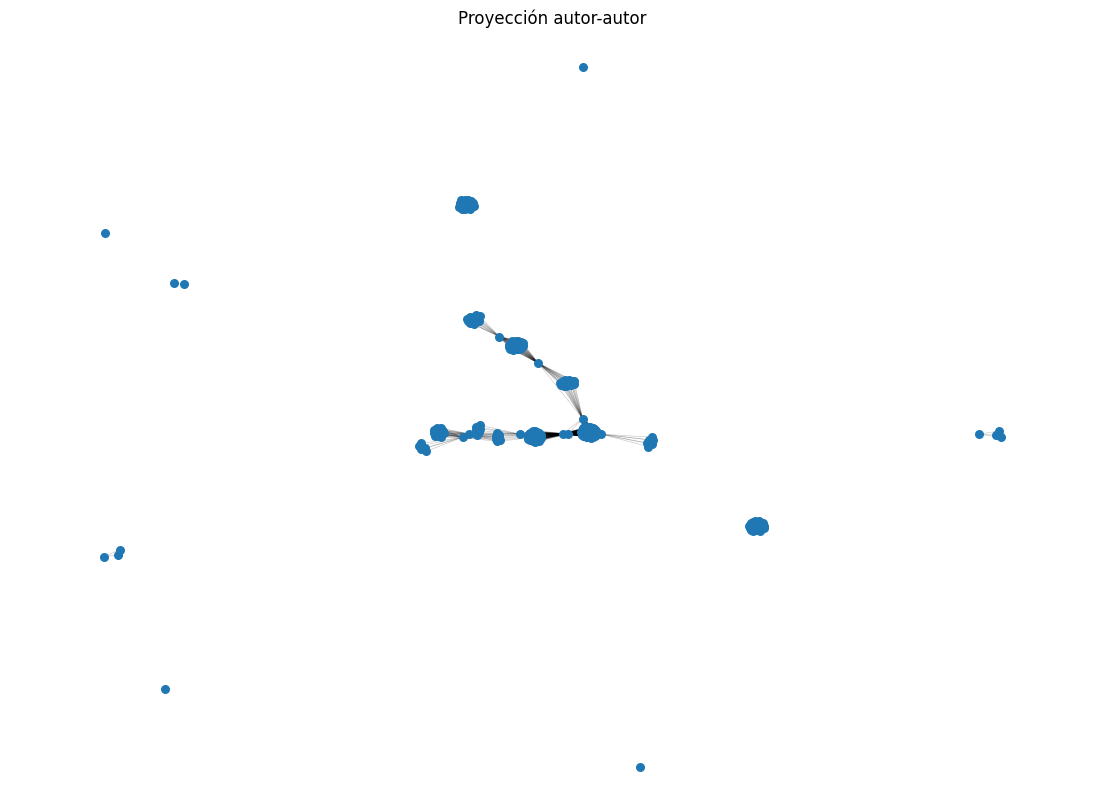

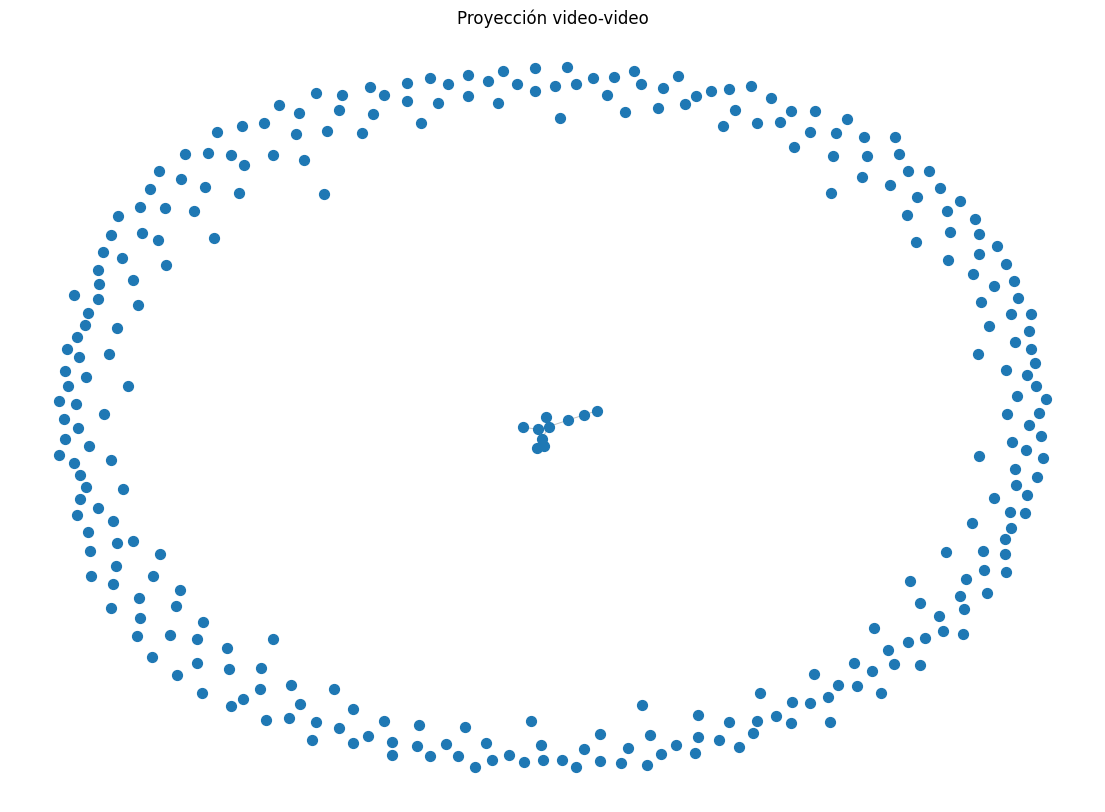

In [29]:
# PROYECCION AUTOR-AUTOR

# Recuperar nodos de tipo autor
autores = [
    nodo
    for nodo, atributos in G.nodes(data=True)
    if atributos["tipo"] == "autor"
]

G_autores = nx.algorithms.bipartite.weighted_projected_graph(
    G,
    autores
)

print("PROYECCION AUTOR-AUTOR")

print("Autores:", G_autores.number_of_nodes())
print("Aristas autor-autor:", G_autores.number_of_edges())

# Mostrar algunas aristas
aristas_autores = pd.DataFrame(
    [
        {
            "autor_1": u,
            "autor_2": v,
            "videos_compartidos": datos_arista["weight"]
        }
        for u, v, datos_arista in G_autores.edges(data=True)
    ]
)

display(
    aristas_autores
    .sort_values(
        "videos_compartidos",
        ascending=False
    )
    .head(10)
)

# PROYECCION VIDEO-VIDEO

videos_red = [
    nodo
    for nodo, atributos in G.nodes(data=True)
    if atributos["tipo"] == "video"
]

G_videos = nx.algorithms.bipartite.weighted_projected_graph(
    G,
    videos_red
)

print("PROYECCION VIDEO-VIDEO")

print("Videos:", G_videos.number_of_nodes())
print("Aristas video-video:", G_videos.number_of_edges())


aristas_videos = pd.DataFrame(
    [
        {
            "video_1": u,
            "video_2": v,
            "autores_compartidos": datos_arista["weight"]
        }
        for u, v, datos_arista in G_videos.edges(data=True)
    ]
)

display(
    aristas_videos
    .sort_values(
        "autores_compartidos",
        ascending=False
    )
    .head(10)
)

# AGREGAR NOMBRES PARA INTERPRETAR MEJOR

nombre_autor = (
    comentarios
    .dropna(subset=["author_channel_id"])
    .drop_duplicates("author_channel_id")
    .set_index("author_channel_id")["author_name"]
    .to_dict()
)

titulo_video = (
    videos
    .drop_duplicates("video_id")
    .set_index("video_id")["title"]
    .to_dict()
)


aristas_autores["nombre_autor_1"] = (
    aristas_autores["autor_1"].map(nombre_autor)
)

aristas_autores["nombre_autor_2"] = (
    aristas_autores["autor_2"].map(nombre_autor)
)


aristas_videos["titulo_video_1"] = (
    aristas_videos["video_1"].map(titulo_video)
)

aristas_videos["titulo_video_2"] = (
    aristas_videos["video_2"].map(titulo_video)
)


print("\nAutores con mayor cantidad de videos compartidos:")

display(
    aristas_autores[
        [
            "nombre_autor_1",
            "nombre_autor_2",
            "videos_compartidos"
        ]
    ]
    .sort_values(
        "videos_compartidos",
        ascending=False
    )
    .head(10)
)


print("\nVideos con mayor cantidad de autores compartidos:")

display(
    aristas_videos[
        [
            "titulo_video_1",
            "titulo_video_2",
            "autores_compartidos"
        ]
    ]
    .sort_values(
        "autores_compartidos",
        ascending=False
    )
    .head(10)
)

# VISUALIZACION PROYECCION AUTOR-AUTOR

plt.figure(figsize=(14, 10))

pos_autores = nx.spring_layout(
    G_autores,
    seed=42
)

nx.draw_networkx_nodes(
    G_autores,
    pos_autores,
    node_size=30
)

nx.draw_networkx_edges(
    G_autores,
    pos_autores,
    alpha=0.20,
    width=0.5
)

plt.title("Proyección autor-autor")
plt.axis("off")
plt.show()

# VISUALIZACION PROYECCION VIDEO-VIDEO

plt.figure(figsize=(14, 10))

pos_videos = nx.spring_layout(
    G_videos,
    seed=42
)

nx.draw_networkx_nodes(
    G_videos,
    pos_videos,
    node_size=50
)

nx.draw_networkx_edges(
    G_videos,
    pos_videos,
    alpha=0.25,
    width=0.7
)

plt.title("Proyección video-video")
plt.axis("off")
plt.show()

# Ejercicio 6

,red,nodos,aristas,densidad,grado_medio,componentes,componente_mayor,porcentaje_componente_mayor,aislados
0,Bipartita autor-video,625,343,0.0018,1.0976,284,286,45.7600,274
1,Proyección autor-autor,332,10732,0.1953,64.6506,10,276,83.1325,4
2,Proyección video-video,293,11,0.0003,0.0751,284,10,3.4130,283


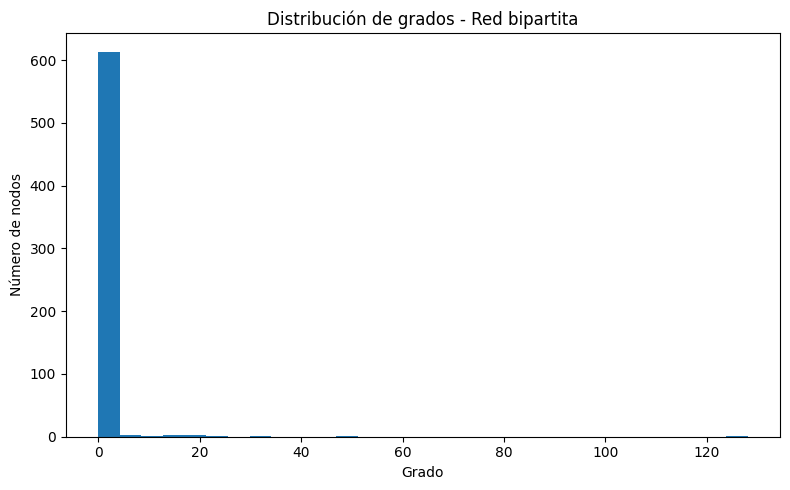

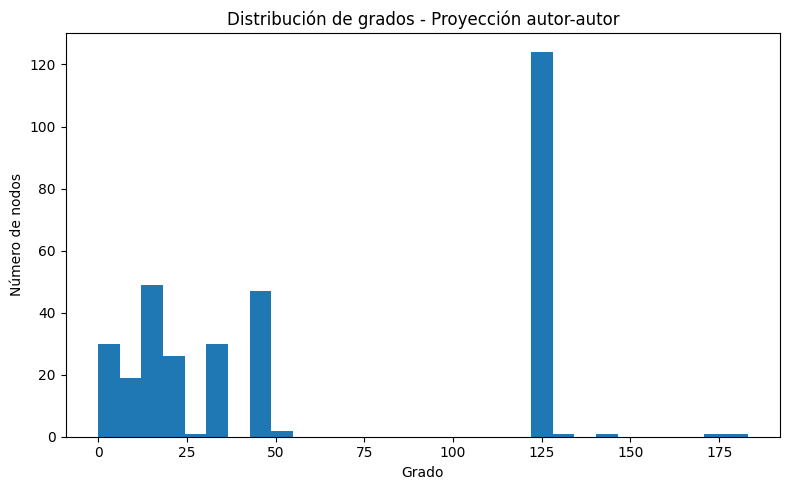

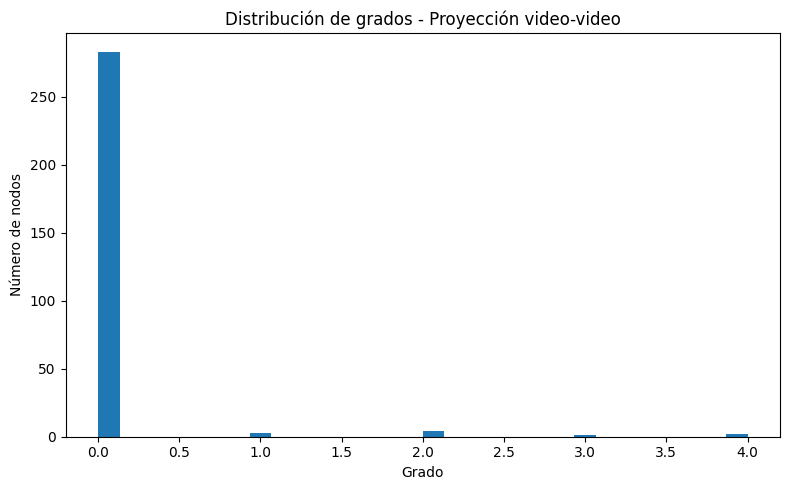

RED BIPARTITA


count    625.000000
mean       1.097600
std        5.859882
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max      128.000000
dtype: float64

AUTOR-AUTOR


count    332.000000
mean      64.650602
std       51.832564
min        0.000000
25%       18.000000
50%       48.000000
75%      127.000000
max      183.000000
dtype: float64

VIDEO-VIDEO


count    293.000000
mean       0.075085
std        0.447015
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        4.000000
dtype: float64


 Red bipartita
--------------------------------------------------
Número de componentes: 284
Tamaño de la componente mayor: 286
Top 10 tamaños: [286, 26, 19, 5, 4, 3, 2, 2, 2, 2]

 Autor-autor
--------------------------------------------------
Número de componentes: 10
Tamaño de la componente mayor: 276
Top 10 tamaños: [276, 25, 18, 4, 3, 2, 1, 1, 1, 1]

 Video-video
--------------------------------------------------
Número de componentes: 284
Tamaño de la componente mayor: 10
Top 10 tamaños: [10, 1, 1, 1, 1, 1, 1, 1, 1, 1]


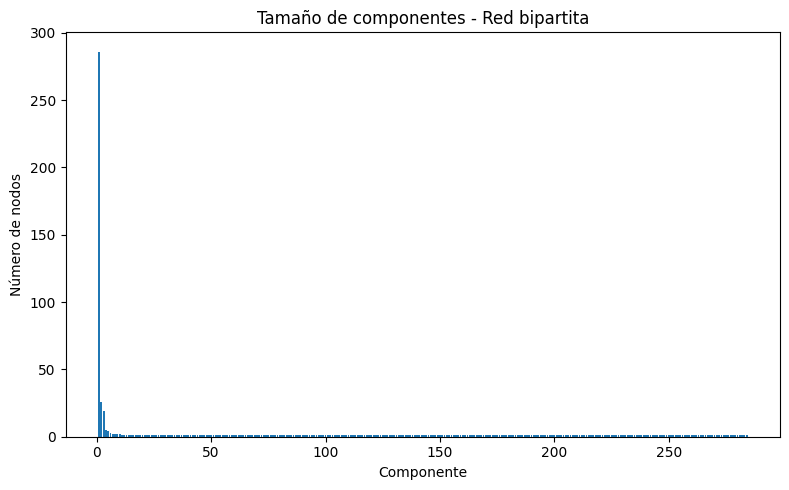

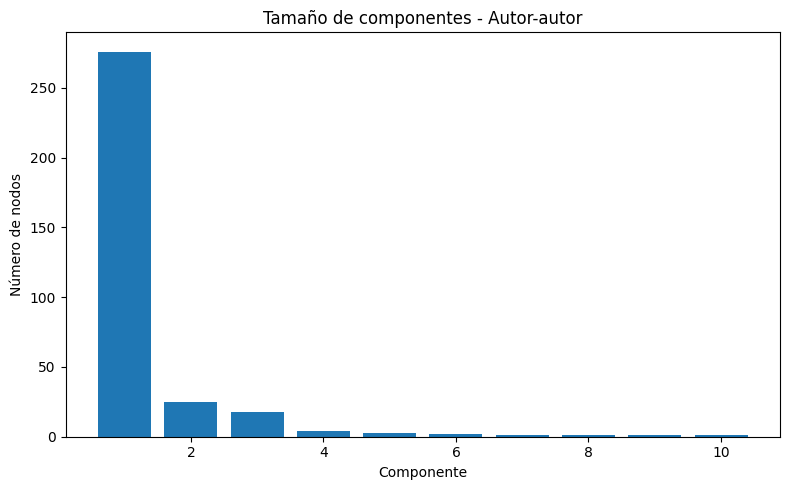

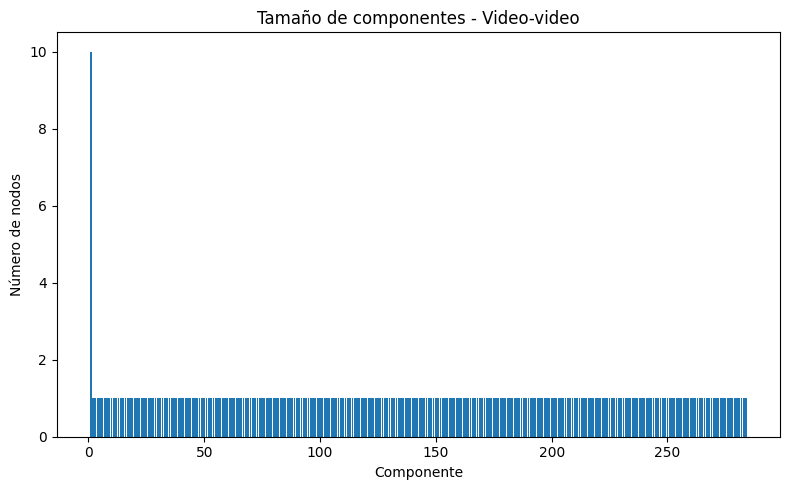

Transitividad autor-autor: 0.984
Clustering promedio autor-autor: 0.972

Transitividad video-video: 0.3158
Clustering promedio video-video: 0.0097
Conectividad de nodos autor-autor: 1
Conectividad de nodos video-video: 1
Autores aislados: 4
Videos aislados: 283
Autores con grado 1: 2
Videos con grado 1: 3
Porcentaje autores grado 1: 0.6 %
Porcentaje videos grado 1: 1.02 %
Autores con mayor grado:


,autor,grado
0,@inge_vergueta,183
1,@Jel.Awesh.M,174
2,@virgiliogarcia3039,145
3,@moisesvaldez4043,133
4,@danyraymundo2942,127
5,@lizardomorataya8274,127
6,@andyB5280,127
7,@cesarandreas7824,127
8,@jor77cas,127
9,@yeniferaguirre4498,127


Videos con mayor grado:


,titulo,grado
0,Qué rico come tu diputado,4
1,Internet: escoger el menos malo,4
2,La cooptación de Walter Mazariegos en la USAC,3
3,Inician los trabajos de recuperación del Puent...,2
4,Conferencia de Prensa del Gobierno de Guatemal...,2
5,Caminar en una ciudad hecha para carros,2
6,Arroz con pollo a la MONOPOLIO,2
7,Capturan a presuntos delincuentes disfrazados ...,1
8,Bloqueos en Guatemala este 31 de agosto por al...,1
9,Capturan a ladrón que había quedado grabado mi...,1


In [30]:
# FUNCION PARA CALCULAR METRICAS GENERALES

def metricas_red(grafo, nombre):

    n_nodos = grafo.number_of_nodes()
    n_aristas = grafo.number_of_edges()

    grados = dict(grafo.degree())

    grado_medio = (
        np.mean(list(grados.values()))
        if n_nodos > 0
        else 0
    )

    densidad = nx.density(grafo)

    componentes = list(
        nx.connected_components(grafo)
    )

    n_componentes = len(componentes)

    tamanio_mayor = (
        max(len(c) for c in componentes)
        if componentes
        else 0
    )

    porcentaje_mayor = (
        tamanio_mayor / n_nodos * 100
        if n_nodos > 0
        else 0
    )

    aislados = list(nx.isolates(grafo))

    return {
        "red": nombre,
        "nodos": n_nodos,
        "aristas": n_aristas,
        "densidad": densidad,
        "grado_medio": grado_medio,
        "componentes": n_componentes,
        "componente_mayor": tamanio_mayor,
        "porcentaje_componente_mayor": porcentaje_mayor,
        "aislados": len(aislados)
    }

# METRICAS GENERALES

resultados_topologia = [
    metricas_red(
        G,
        "Bipartita autor-video"
    ),
    metricas_red(
        G_autores,
        "Proyección autor-autor"
    ),
    metricas_red(
        G_videos,
        "Proyección video-video"
    )
]

tabla_topologia = pd.DataFrame(
    resultados_topologia
)

display(
    tabla_topologia.round(4)
)

# DISTRIBUCION DE GRADOS

def graficar_grados(grafo, titulo):

    grados = [
        grado
        for _, grado in grafo.degree()
    ]

    plt.figure(figsize=(8, 5))

    plt.hist(
        grados,
        bins=30
    )

    plt.title(
        f"Distribución de grados - {titulo}"
    )

    plt.xlabel("Grado")
    plt.ylabel("Número de nodos")

    plt.tight_layout()
    plt.show()


graficar_grados(
    G,
    "Red bipartita"
)

graficar_grados(
    G_autores,
    "Proyección autor-autor"
)

graficar_grados(
    G_videos,
    "Proyección video-video"
)

def resumen_grados(grafo):

    grados = pd.Series(
        dict(grafo.degree())
    )

    return grados.describe()


print("RED BIPARTITA")
display(resumen_grados(G))

print("AUTOR-AUTOR")
display(resumen_grados(G_autores))

print("VIDEO-VIDEO")
display(resumen_grados(G_videos))

# COMPONENTES CONEXOS

def analizar_componentes(grafo, nombre):

    componentes = sorted(
        nx.connected_components(grafo),
        key=len,
        reverse=True
    )

    tamanios = [
        len(c)
        for c in componentes
    ]

    print("\n", nombre)
    print("-" * 50)

    print(
        "Número de componentes:",
        len(componentes)
    )

    print(
        "Tamaño de la componente mayor:",
        tamanios[0] if tamanios else 0
    )

    print(
        "Top 10 tamaños:",
        tamanios[:10]
    )

    return componentes


componentes_bipartita = analizar_componentes(
    G,
    "Red bipartita"
)

componentes_autores = analizar_componentes(
    G_autores,
    "Autor-autor"
)

componentes_videos = analizar_componentes(
    G_videos,
    "Video-video"
)

def graficar_componentes(grafo, titulo):

    tamanios = sorted(
        [
            len(c)
            for c in nx.connected_components(grafo)
        ],
        reverse=True
    )

    plt.figure(figsize=(8, 5))

    plt.bar(
        range(1, len(tamanios) + 1),
        tamanios
    )

    plt.title(
        f"Tamaño de componentes - {titulo}"
    )

    plt.xlabel("Componente")
    plt.ylabel("Número de nodos")

    plt.tight_layout()
    plt.show()


graficar_componentes(
    G,
    "Red bipartita"
)

graficar_componentes(
    G_autores,
    "Autor-autor"
)

graficar_componentes(
    G_videos,
    "Video-video"
)

# COHESION Y TRANSITIVIDAD

transitividad_autores = nx.transitivity(
    G_autores
)

transitividad_videos = nx.transitivity(
    G_videos
)

clustering_autores = nx.average_clustering(
    G_autores
)

clustering_videos = nx.average_clustering(
    G_videos
)

print(
    "Transitividad autor-autor:",
    round(transitividad_autores, 4)
)

print(
    "Clustering promedio autor-autor:",
    round(clustering_autores, 4)
)

print()

print(
    "Transitividad video-video:",
    round(transitividad_videos, 4)
)

print(
    "Clustering promedio video-video:",
    round(clustering_videos, 4)
)

# Componente gigante autor-autor

mayor_autores = max(
    nx.connected_components(G_autores),
    key=len
)

G_autores_gigante = G_autores.subgraph(
    mayor_autores
).copy()


# Componente gigante video-video

mayor_videos = max(
    nx.connected_components(G_videos),
    key=len
)

G_videos_gigante = G_videos.subgraph(
    mayor_videos
).copy()

print(
    "Conectividad de nodos autor-autor:",
    nx.node_connectivity(
        G_autores_gigante
    )
)

print(
    "Conectividad de nodos video-video:",
    nx.node_connectivity(
        G_videos_gigante
    )
)

# AISLADOS

aislados_autores = list(
    nx.isolates(G_autores)
)

aislados_videos = list(
    nx.isolates(G_videos)
)

print(
    "Autores aislados:",
    len(aislados_autores)
)

print(
    "Videos aislados:",
    len(aislados_videos)
)

# PERIFÉRICOS

perifericos_autores = [
    nodo
    for nodo, grado in G_autores.degree()
    if grado == 1
]

perifericos_videos = [
    nodo
    for nodo, grado in G_videos.degree()
    if grado == 1
]

print(
    "Autores con grado 1:",
    len(perifericos_autores)
)

print(
    "Videos con grado 1:",
    len(perifericos_videos)
)

print(
    "Porcentaje autores grado 1:",
    round(
        len(perifericos_autores)
        / G_autores.number_of_nodes()
        * 100,
        2
    ),
    "%"
)

print(
    "Porcentaje videos grado 1:",
    round(len(perifericos_videos)/ G_videos.number_of_nodes()* 100,2),"%")

# NODOS CON MAYOR GRADO

top_autores_grado = sorted(
    G_autores.degree(),
    key=lambda x: x[1],
    reverse=True
)[:10]

top_videos_grado = sorted(
    G_videos.degree(),
    key=lambda x: x[1],
    reverse=True
)[:10]


df_top_autores = pd.DataFrame(
    top_autores_grado,
    columns=[
        "author_channel_id",
        "grado"
    ]
)

df_top_autores["autor"] = (
    df_top_autores[
        "author_channel_id"
    ].map(nombre_autor)
)


df_top_videos = pd.DataFrame(
    top_videos_grado,
    columns=[
        "video_id",
        "grado"
    ]
)

df_top_videos["titulo"] = (
    df_top_videos[
        "video_id"
    ].map(titulo_video)
)


print("Autores con mayor grado:")
display(
    df_top_autores[
        ["autor", "grado"]
    ]
)


print("Videos con mayor grado:")
display(
    df_top_videos[
        ["titulo", "grado"]
    ]
)

La red bipartita autor-video presenta una estructura altamente dispersa. Está formada por 625 nodos y 343 aristas, con una densidad de 0.0018 y un grado medio de aproximadamente 1.10. La mediana del grado es 1, mientras que el máximo alcanza 128, lo que muestra que la mayoría de los nodos presenta pocas conexiones y una pequeña cantidad concentra gran parte de la participación.

La red está dividida en 284 componentes conexos. La componente principal contiene 286 nodos, equivalentes aproximadamente al 45.76 % de la red. Esto muestra que existe un núcleo importante de participación conectada, pero también una cantidad considerable de estructuras separadas.
Sobre los nodos aislados: un video aislado indica que no presenta participación dentro de los comentarios recolectados, pero no permite afirmar que el video no tenga comentarios o audiencia en YouTube.

La proyección autor-autor presenta una estructura considerablemente más conectada. Sus 332 autores forman 10,732 aristas, con una densidad de 0.1953 y un grado medio de aproximadamente 64.65. Además, la componente principal contiene 276 autores, equivalentes al 83.13 % del total.

La transitividad de 0.984 y el coeficiente de agrupamiento promedio de 0.972 indican una fuerte tendencia a formar grupos densamente conectados. Sin embargo, este resultado se explica en gran medida por la definición de la proyección: cuando muchos autores comentan en un mismo video, todos quedan conectados entre sí. Esto significa que el alto agrupamiento representa participación en contenidos comunes y no relaciones sociales directas.

Algunos autores presentan grados considerablemente superiores al resto. El mayor grado corresponde a @inge_vergueta, con 183 conexiones, seguido por @Jel.Awesh.M con 174 y @virgiliogarcia3039 con 145. Estos autores coincidieron con una gran cantidad de otros participantes en los videos analizados. Sin embargo, un grado alto no implica por sí solo influencia ni comunicación directa; estas características deberán analizarse posteriormente mediante medidas específicas de centralidad.